In [2]:
# import os
# import csv
# from pathlib import Path
#
# DATASET_ROOT = "pad_dataset"
#
# FOLDERS = {
#     "real_fringe": "real_fringe",
#     "attack_print_bw": "print_bw",
#     "attack_print_color": "print_color",
#     "attack_screen": "screen"
# }
# #bonafied == real_fringe
# OUTPUT_CSV = "manifest.csv"
#
# def create_manifest():
#     rows = []
#     dataset_root = Path(DATASET_ROOT)
#
#     for folder_name, category in FOLDERS.items():
#         folder_path = dataset_root / folder_name
#
#         if not folder_path.exists():
#             print(f"Warning: {folder_path} does not exist.")
#             continue
#
#         for file in folder_path.rglob("*"):
#             if file.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
#
#                 # Determine class label
#                 if folder_name == "real_fringe":
#                     class_label = "real_fringe"
#                     attack_type = ""
#                 else:
#                     class_label = "attack"
#                     attack_type = category
#
#                 rows.append({
#                     "file_path": str(file.as_posix()),
#                     "class": class_label,
#                     "attack_type": attack_type
#                 })
#
#     # Write CSV
#     with open(OUTPUT_CSV, "w", newline="") as csvfile:
#         writer = csv.DictWriter(csvfile, fieldnames=["file_path", "class", "attack_type"])
#         writer.writeheader()
#         for row in rows:
#             writer.writerow(row)
#
#     print(f"Manifest created → {OUTPUT_CSV}")
#     print(f"Total images found: {len(rows)}")
# create_manifest()


import os
import csv
import random

DATASET_DIR = "CroppedFaces"
OUTPUT_MANIFEST = "manifest.csv"

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

class_to_label = {cls: idx for idx, cls in enumerate(class_names)}
class_wise_files = {cls: [] for cls in class_names}

for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)

    for root, _, files in os.walk(cls_path):
        for file in files:
            if file.lower().endswith(IMAGE_EXTENSIONS):
                class_wise_files[cls].append(os.path.join(root, file))

manifest_rows = []

for cls, files in class_wise_files.items():
    random.shuffle(files)

    total = len(files)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    for i, file_path in enumerate(files):
        if i < train_end:
            split = "train"
        elif i < val_end:
            split = "val"
        else:
            split = "test"

        if cls == "real_fringe":
            attack_type = ""
        else:
            attack_type = cls.replace("attack_", "")

        manifest_rows.append([
            file_path,
            class_to_label[cls],
            cls,
            attack_type,
            split
        ])

with open(OUTPUT_MANIFEST, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file_path", "label", "class_name", "attack_type", "split"])
    writer.writerows(manifest_rows)

print(f"Manifest created: {OUTPUT_MANIFEST}")
print(f"Total samples: {len(manifest_rows)}")

Manifest created: manifest.csv
Total samples: 28410


In [3]:
import csv
import json
import random
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

# CONFIG
MANIFEST_IN = "manifest.csv"
MANIFEST_OUT = "manifest_with_splits.csv"
SUMMARY_OUT = "splits_summary.json"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42


def read_manifest(path):
    rows = []
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(r)
    return rows, reader.fieldnames


def write_manifest(path, rows, fieldnames):
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def stratified_split(rows, train_ratio, val_ratio, seed):

    for r in rows:
        atk = r.get("attack_type", "") or ""
        cls = r.get("class_name", "")
        r["_stratify_key"] = f"{cls}|{atk}"

    keys = [r["_stratify_key"] for r in rows]

    train_rows, rest_rows = train_test_split(
        rows,
        train_size=train_ratio,
        random_state=seed,
        stratify=keys
    )

    rest_ratio = val_ratio / (val_ratio + TEST_RATIO)

    rest_keys = [r["_stratify_key"] for r in rest_rows]

    val_rows, test_rows = train_test_split(
        rest_rows,
        train_size=rest_ratio,
        random_state=seed,
        stratify=rest_keys
    )

    for r in train_rows:
        r["split"] = "train"

    for r in val_rows:
        r["split"] = "val"

    for r in test_rows:
        r["split"] = "test"

    return train_rows + val_rows + test_rows


def summarize(rows):

    cnt = Counter([r["split"] for r in rows])

    by_class = {}

    for split in ("train", "val", "test"):

        subset = [r for r in rows if r["split"] == split]

        counts = Counter([
            (r.get("class_name", ""), r.get("attack_type", ""))
            for r in subset
        ])

        by_class[split] = {
            f"{cls}|{atk}": count
            for (cls, atk), count in counts.items()
        }

    return {"counts": dict(cnt), "by_class": by_class}


def split_manifest():

    random.seed(RANDOM_SEED)

    manifest_path = Path(MANIFEST_IN)

    if not manifest_path.exists():
        print(f"ERROR: {MANIFEST_IN} not found. Run create_manifest.py first.")
        return

    rows, fieldnames = read_manifest(MANIFEST_IN)

    if "split" in fieldnames:
        print("Warning: 'split' column already exists and will be overwritten.")

    rows_with_splits = stratified_split(rows, TRAIN_RATIO, VAL_RATIO, RANDOM_SEED)

    for r in rows_with_splits:
        if "_stratify_key" in r:
            del r["_stratify_key"]

    out_fieldnames = list(fieldnames)

    if "split" not in out_fieldnames:
        out_fieldnames.append("split")

    write_manifest(MANIFEST_OUT, rows_with_splits, out_fieldnames)

    summary = summarize(rows_with_splits)

    with open(SUMMARY_OUT, "w") as jf:
        json.dump(summary, jf, indent=2)

    print(f"Wrote: {MANIFEST_OUT}")
    print(f"Wrote: {SUMMARY_OUT}")
    print("Split counts:", summary["counts"])


split_manifest()

Wrote: manifest_with_splits.csv
Wrote: splits_summary.json
Split counts: {'train': 19887, 'val': 4261, 'test': 4262}


In [3]:
# # Preprocessing pipeline
#
# import os, sys, math
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import cv2
# import matplotlib.pyplot as plt
# from tqdm import tqdm
#
# # Config
# MANIFEST = Path("manifest_with_splits.csv")
# OUT_ROOT = Path("processed")
# IMG_SIZE = 224
# EXAMPLES_PER_SPLIT = 2  # how many example files to show/save per split
#
# if not MANIFEST.exists():
#     raise FileNotFoundError(f"{MANIFEST} not found. Make sure you ran the split step and are in project root.")
#
# df = pd.read_csv(MANIFEST)
# if "file_path" not in df.columns or "split" not in df.columns:
#     raise ValueError("manifest_with_splits.csv must contain 'file_path' and 'split' columns.")
#
# OUT_ROOT.mkdir(parents=True, exist_ok=True)
#
# def load_image_grayscale(path, max_dim=1600):
#     img = cv2.imread(str(path), cv2.IMREAD_COLOR)
#     if img is None:
#         raise FileNotFoundError(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
#     h,w = gray.shape
#     if max(h,w) > max_dim:
#         scale = max_dim / max(h,w)
#         gray = cv2.resize(gray, (int(w*scale), int(h*scale)))
#     return gray
#
# def dog_bandpass(img, sigma_small=1.0, sigma_large=3.0):
#     g1 = cv2.GaussianBlur(img, (0,0), sigmaX=sigma_small)
#     g2 = cv2.GaussianBlur(img, (0,0), sigmaX=sigma_large)
#     dog = g1 - g2
#     return dog
#
# def gradient_magnitude(img):
#     gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
#     gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
#     mag = np.sqrt(gx*gx + gy*gy)
#     return mag
#
# def central_crop_and_resize(img, target=IMG_SIZE):
#     h,w = img.shape[:2]
#     side = min(h,w)
#     cy, cx = h//2, w//2
#     y1 = max(0, cy - side//2)
#     x1 = max(0, cx - side//2)
#     cropped = img[y1:y1+side, x1:x1+side]
#     resized = cv2.resize(cropped, (target, target), interpolation=cv2.INTER_LINEAR)
#     return resized
#
# def normalize_channel(ch):
#     m = np.nanmean(ch)
#     s = np.nanstd(ch) + 1e-8
#     low = m - 3*s
#     high = m + 3*s
#     ch = np.clip(ch, low, high)
#     ch = (ch - low) / (high - low + 1e-8)
#     return ch
# # low pass fories fillter
# #
# def preprocess_path(path):
#     gray = load_image_grayscale(path)
#     gray_c = central_crop_and_resize(gray, IMG_SIZE)
#     ch0 = normalize_channel(gray_c)
#     dog = dog_bandpass(gray_c, sigma_small=1.0, sigma_large=4.0)
#     ch1 = normalize_channel(dog)
#     grad = gradient_magnitude(gray_c)
#     ch2 = normalize_channel(grad)
#     tensor = np.stack([ch0, ch1, ch2], axis=-1).astype(np.float32)
#     return tensor
#
# # Process examples per split for preview and saving
# examples = {}
# for split in ["train","val","test"]:
#     subset = df[df["split"]==split]
#     if subset.shape[0] == 0:
#         continue
#     examples[split] = subset["file_path"].values[:EXAMPLES_PER_SPLIT].tolist()
#     (OUT_ROOT / split).mkdir(parents=True, exist_ok=True)
#
# saved_examples = []
# for split, paths in examples.items():
#     for p in paths:
#         pth = Path(p)
#         try:
#             tensor = preprocess_path(pth)
#         except Exception as e:
#             print("Error processing", p, ":", e)
#             continue
#         base = pth.stem
#         outfn = OUT_ROOT / split / f"{base}_proc.npy"
#         np.save(str(outfn), tensor)
#         saved_examples.append((split, pth.name, outfn, tensor))
#
# # Display before/after for saved examples
# n = len(saved_examples)
# if n == 0:
#     print("No examples found for display.")
# else:
#     cols = min(3, n)
#     rows = (n + cols - 1) // cols
#     plt.figure(figsize=(4*cols, 3*rows*2))
#     for i, (split, name, outfn, tensor) in enumerate(saved_examples):
#         # original
#         orig_path = df[df["file_path"].str.endswith(name)].iloc[0]["file_path"]
#         orig = cv2.imread(str(Path(orig_path)))
#         orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
#         plt.subplot(rows*2, cols, i+1)
#         plt.imshow(orig_rgb)
#         plt.title(f"{split}: {name}\n(original)")
#         plt.axis('off')
#
#         plt.subplot(rows*2, cols, i+1+cols)
#         disp = np.clip(tensor, 0, 1)
#         disp_img = (disp * 255).astype(np.uint8)
#         plt.imshow(disp_img)
#         plt.title(f"{split}: processed (gray|DoG|grad)")
#         plt.axis('off')
#     plt.tight_layout()
#
# print("Saved example preprocessed .npy files under:", OUT_ROOT)
# print("Function available: preprocess_path(path) -> (224,224,3) float32 in [0,1].")


In [4]:
# Preprocessing pipeline
import os, sys, math
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

# Config
MANIFEST = Path("manifest_with_splits.csv")
OUT_ROOT = Path("processed")
IMG_SIZE = 224
EXAMPLES_PER_SPLIT = 2

if not MANIFEST.exists():
    raise FileNotFoundError(f"{MANIFEST} not found.")

df = pd.read_csv(MANIFEST)

if "file_path" not in df.columns or "split" not in df.columns:
    raise ValueError("manifest must contain 'file_path' and 'split'")

OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ---------- IMAGE LOADING ----------
def load_image_grayscale(path, max_dim=1600):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

    h, w = gray.shape
    if max(h, w) > max_dim:
        scale = max_dim / max(h, w)
        gray = cv2.resize(gray, (int(w * scale), int(h * scale)))

    return gray


# ---------- CLAHE ----------
def apply_clahe(img):
    img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img_uint8)
    return enhanced.astype(np.float32)


# ---------- DoG ----------
def dog_bandpass(img, sigma_small=1.0, sigma_large=4.0):
    g1 = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma_small)
    g2 = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma_large)
    return g1 - g2


# ---------- Gradient ----------
def gradient_magnitude(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx * gx + gy * gy)
    return mag


# ---------- Crop + Resize ----------
def central_crop_and_resize(img, target=IMG_SIZE):
    h, w = img.shape
    side = min(h, w)

    cy, cx = h // 2, w // 2
    y1 = max(0, cy - side // 2)
    x1 = max(0, cx - side // 2)

    cropped = img[y1:y1 + side, x1:x1 + side]
    resized = cv2.resize(cropped, (target, target))

    return resized


# ---------- Normalize ----------
def normalize_channel(ch):
    m = np.nanmean(ch)
    s = np.nanstd(ch) + 1e-8

    low = m - 3 * s
    high = m + 3 * s

    ch = np.clip(ch, low, high)
    ch = (ch - low) / (high - low + 1e-8)

    return ch


# ---------- MAIN PREPROCESS ----------
def preprocess_path(path):

    gray = load_image_grayscale(path)

    gray_c = central_crop_and_resize(gray, IMG_SIZE)

    # CLAHE enhancement
    clahe_img = apply_clahe(gray_c)

    # Channel 0 : CLAHE enhanced grayscale
    ch0 = normalize_channel(clahe_img)

    # Channel 1 : DoG
    dog = dog_bandpass(clahe_img)
    ch1 = normalize_channel(dog)

    # Channel 2 : Gradient magnitude
    grad = gradient_magnitude(clahe_img)
    ch2 = normalize_channel(grad)

    tensor = np.stack([ch0, ch1, ch2], axis=-1).astype(np.float32)

    return tensor


# ---------- SAVE EXAMPLES ----------
examples = {}

for split in ["train", "val", "test"]:
    subset = df[df["split"] == split]

    if subset.shape[0] == 0:
        continue

    examples[split] = subset["file_path"].values[:EXAMPLES_PER_SPLIT].tolist()

    (OUT_ROOT / split).mkdir(parents=True, exist_ok=True)


saved_examples = []

for split, paths in examples.items():

    for p in paths:

        pth = Path(p)

        try:
            tensor = preprocess_path(pth)
        except Exception as e:
            print("Error:", p, e)
            continue

        base = pth.stem
        outfn = OUT_ROOT / split / f"{base}_proc.npy"

        np.save(str(outfn), tensor)

        saved_examples.append((split, pth.name, outfn, tensor))


print("Saved example preprocessed files in:", OUT_ROOT)
print("Output tensor shape:", "(224,224,3)")

Saved example preprocessed files in: processed
Output tensor shape: (224,224,3)


In [14]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score
import torchvision.models as models
from tqdm import tqdm

# ==================== CONFIG ====================
MANIFEST = "manifest_with_splits.csv"
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 5
PATIENCE = 5
BEST_MODEL_PATH = "best_model.pt"
NUM_WORKERS = 0

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==================== PREPROCESSING ====================

processed_image_counter = 0

def load_image_grayscale_np(path, max_dim=1600):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

    h, w = gray.shape
    if max(h, w) > max_dim:
        scale = max_dim / max(h, w)
        gray = cv2.resize(gray, (int(w * scale), int(h * scale)))

    return gray


def apply_clahe_np(img):
    img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img_uint8)
    return enhanced.astype(np.float32)


def central_crop_and_resize_np(img, target=IMG_SIZE):
    h, w = img.shape
    side = min(h, w)

    cy, cx = h // 2, w // 2
    y1 = max(0, cy - side // 2)
    x1 = max(0, cx - side // 2)

    cropped = img[y1:y1 + side, x1:x1 + side]
    resized = cv2.resize(cropped, (target, target))

    return resized


def normalize_channel_np(ch):
    m = np.nanmean(ch)
    s = np.nanstd(ch) + 1e-8

    low = m - 3 * s
    high = m + 3 * s

    ch = np.clip(ch, low, high)
    ch = (ch - low) / (high - low + 1e-8)

    return ch


def dog_bandpass_np(img, sigma_small=1.0, sigma_large=4.0):
    g1 = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma_small)
    g2 = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma_large)
    return g1 - g2


def gradient_magnitude_np(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx * gx + gy * gy)
    return mag


def preprocess_path_np(path):

    global processed_image_counter

    gray = load_image_grayscale_np(path)
    gray_c = central_crop_and_resize_np(gray, IMG_SIZE)

    clahe = apply_clahe_np(gray_c)

    ch0 = normalize_channel_np(clahe)

    dog = dog_bandpass_np(clahe, sigma_small=1.0, sigma_large=4.0)
    ch1 = normalize_channel_np(dog)

    grad = gradient_magnitude_np(clahe)
    ch2 = normalize_channel_np(grad)

    tensor = np.stack([ch0, ch1, ch2], axis=-1).astype(np.float32)

    tensor = np.clip(tensor, 0.0, 1.0)

    processed_image_counter += 1

    if processed_image_counter % 100 == 0:
        print(f"Processed images so far: {processed_image_counter}")

    return tensor


# ==================== DATASET ====================

class PADDataset(Dataset):

    def __init__(self, manifest_csv, split, augment=False):

        df = pd.read_csv(manifest_csv)

        class_names = sorted(df["class_name"].unique())
        self.label_map = {cls: i for i, cls in enumerate(class_names)}

        print("Class mapping:", self.label_map)

        df["label_int"] = df["class_name"].map(self.label_map)

        sub = df[df["split"] == split].reset_index(drop=True)

        self.paths = sub["file_path"].values
        self.labels = sub["label_int"].values
        self.augment = augment

        print(f"{split} dataset loaded: {len(self.paths)} images")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        path = self.paths[idx]
        label = self.labels[idx]

        img = preprocess_path_np(path)

        img = torch.from_numpy(img).permute(2, 0, 1).float()

        label = torch.tensor(label, dtype=torch.long)

        return img, label


# ==================== LOAD DATA ====================

df_temp = pd.read_csv(MANIFEST)
NUM_CLASSES = len(df_temp["class_name"].unique())

train_ds = PADDataset(MANIFEST, "train", augment=True)
val_ds = PADDataset(MANIFEST, "val")
test_ds = PADDataset(MANIFEST, "test")

print("\nTotal training images:", len(train_ds))
print("Total validation images:", len(val_ds))
print("Total testing images:", len(test_ds))

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, BATCH_SIZE)
test_loader = DataLoader(test_ds, BATCH_SIZE)

print("\nTrain batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


# ==================== MODEL ====================

class PADMobileNetV2(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        base = models.mobilenet_v2(weights=None)

        base.classifier = nn.Sequential(
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        self.base = base

    def forward(self, x):
        return self.base(x)


model = PADMobileNetV2(NUM_CLASSES).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

criterion = nn.CrossEntropyLoss()


# ==================== EVALUATE ====================

def evaluate(model, loader, name="Eval"):

    model.eval()

    all_preds = []
    all_labels = []

    total_loss = 0
    batches = 0
    processed = 0

    with torch.no_grad():

        loop = tqdm(loader, desc=name)

        for imgs, labels in loop:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            total_loss += loss.item()
            batches += 1

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            processed += imgs.size(0)

            loop.set_postfix(images_processed=processed)

    acc = accuracy_score(all_labels, all_preds)

    return total_loss / batches, acc


# ==================== TRAIN ====================

best_acc = 0
no_improve = 0

print("\nStarting training...\n")

for epoch in range(EPOCHS):

    epoch_start = time.time()

    print(f"\n========== Epoch {epoch+1}/{EPOCHS} ==========")

    model.train()

    running_loss = 0
    running_correct = 0
    total_samples = 0

    processed_epoch = 0

    loop = tqdm(train_loader, desc="Training")

    for imgs, labels in loop:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        running_correct += (preds == labels).sum().item()

        total_samples += labels.size(0)

        processed_epoch += imgs.size(0)

        loop.set_postfix(
            loss=loss.item(),
            images_processed=processed_epoch
        )

    train_loss = running_loss / len(train_loader)
    train_acc = running_correct / total_samples

    val_loss, val_acc = evaluate(model, val_loader, "Validation")

    epoch_time = time.time() - epoch_start

    print("\nEpoch Summary")
    print("Images processed this epoch:", processed_epoch)
    print("Training Loss:", train_loss)
    print("Training Accuracy:", train_acc)
    print("Validation Loss:", val_loss)
    print("Validation Accuracy:", val_acc)
    print("Epoch time:", round(epoch_time, 2), "seconds")

    if val_acc > best_acc:

        best_acc = val_acc
        no_improve = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best model saved")

    else:

        no_improve += 1

        print("No improvement:", no_improve)

        if no_improve >= PATIENCE:
            print("Early stopping triggered")
            break


# ==================== TEST ====================

print("\nLoading best model...")

model.load_state_dict(torch.load(BEST_MODEL_PATH))

print("\nRunning test evaluation...")

test_loss, test_acc = evaluate(model, test_loader, "Testing")

print("\n========== FINAL TEST RESULTS ==========")

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU count: 1
Using device: cuda
Class mapping: {'attack_print_bw': 0, 'attack_print_color': 1, 'attack_screen': 2, 'real_fringe': 3, 'real_no_fringe': 4}
train dataset loaded: 19887 images
Class mapping: {'attack_print_bw': 0, 'attack_print_color': 1, 'attack_screen': 2, 'real_fringe': 3, 'real_no_fringe': 4}
val dataset loaded: 4261 images
Class mapping: {'attack_print_bw': 0, 'attack_print_color': 1, 'attack_screen': 2, 'real_fringe': 3, 'real_no_fringe': 4}
test dataset loaded: 4262 images

Total training images: 19887
Total validation images: 4261
Total testing images: 4262

Train batches: 2486
Validation batches: 533
Test batches: 533

Starting training...


========== Epoch 1/5 ==========


Training:   0%|          | 12/2486 [00:04<13:25,  3.07it/s, images_processed=96, loss=1.39]

Processed images so far: 100


Training:   1%|          | 25/2486 [00:08<15:21,  2.67it/s, images_processed=200, loss=1.19]

Processed images so far: 200


...

Processed images so far: 124800


Testing:  98%|█████████▊| 520/533 [03:10<00:05,  2.42it/s, images_processed=4160]

Processed images so far: 124900


Testing: 100%|██████████| 533/533 [03:15<00:00,  2.72it/s, images_processed=4262]

Processed images so far: 125000

========== FINAL TEST RESULTS ==========
Test Loss: 0.054701913893063094
Test Accuracy: 0.9791177850774284


In [15]:
def get_predictions(model, loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labs in loader:

            imgs = imgs.to(device)
            labs = labs.cpu().numpy()

            outputs = model(imgs)                 # [B, num_classes]
            probs = torch.softmax(outputs, dim=1) # convert to probabilities

            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labs)

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return all_probs, all_preds, all_labels


# Usage
test_probs, test_preds, test_labels = get_predictions(model, test_loader, device)

print("Probabilities shape:", test_probs.shape)
print("Predictions shape:", test_preds.shape)
print("Labels shape:", test_labels.shape)

Processed images so far: 125100
Processed images so far: 125200
Processed images so far: 125300
Processed images so far: 125400
Processed images so far: 125500
Processed images so far: 125600
Processed images so far: 125700
Processed images so far: 125800
Processed images so far: 125900
Processed images so far: 126000
Processed images so far: 126100
Processed images so far: 126200
Processed images so far: 126300
Processed images so far: 126400
Processed images so far: 126500
Processed images so far: 126600
Processed images so far: 126700
Processed images so far: 126800
Processed images so far: 126900
Processed images so far: 127000
Processed images so far: 127100
Processed images so far: 127200
Processed images so far: 127300
Processed images so far: 127400
Processed images so far: 127500
Processed images so far: 127600
Processed images so far: 127700
Processed images so far: 127800
Processed images so far: 127900


KeyboardInterrupt: 

[Collect] Collected 24 images

Class distribution in shown images:
attack_print_bw: 7
attack_print_color: 9
attack_screen: 6
real_fringe: 0


IndexError: list index out of range

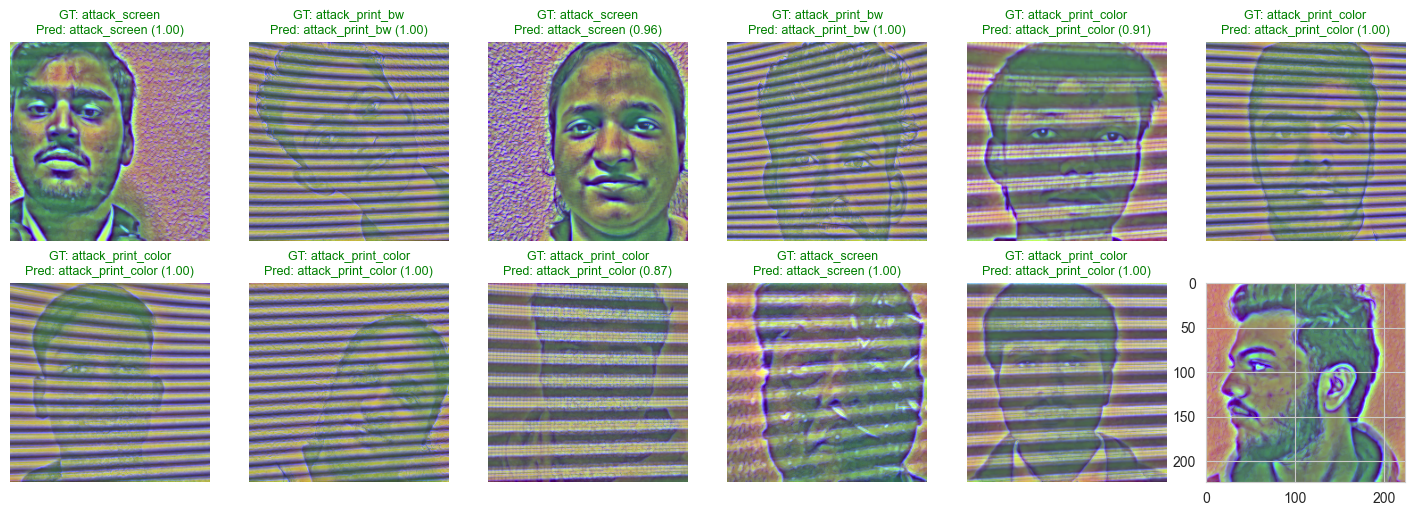

In [16]:
import matplotlib.pyplot as plt
import math
import numpy as np
import torch

# update according to your dataset classes
CLASS_NAMES = [
    "attack_print_bw",
    "attack_print_color",
    "attack_screen",
    "real_fringe"
]

def label_name(x: int) -> str:
    return CLASS_NAMES[x]


def collect_test_samples(model, loader, device, max_images=32):

    model.eval()

    images_list = []
    labels_list = []
    preds_list = []
    probs_list = []

    unique_labels = set()

    with torch.no_grad():
        for imgs, labs in loader:

            imgs = imgs.to(device)

            outputs = model(imgs)                      # [B, num_classes]
            probs = torch.softmax(outputs, dim=1)      # probabilities
            preds = torch.argmax(probs, dim=1)         # predicted class

            probs_np = probs.cpu().numpy()
            preds_np = preds.cpu().numpy()
            labs_np = labs.numpy()

            for i in range(len(labs_np)):

                images_list.append(imgs.cpu()[i])        # CHW
                labels_list.append(int(labs_np[i]))
                preds_list.append(int(preds_np[i]))
                probs_list.append(float(probs_np[i][preds_np[i]]))

                unique_labels.add(int(labs_np[i]))

                if len(images_list) >= max_images:
                    print(f"[Collect] Collected {len(images_list)} images")
                    return images_list, labels_list, preds_list, probs_list

    print(f"[Collect] Reached end of loader with {len(images_list)} images")
    return images_list, labels_list, preds_list, probs_list


def show_test_grid(model, test_loader, device, max_images=24, n_cols=6):

    imgs_list, labels_list, preds_list, probs_list = collect_test_samples(
        model, test_loader, device, max_images=max_images
    )

    n = len(imgs_list)

    if n == 0:
        print("No images collected from test_loader.")
        return

    labels_arr = np.array(labels_list)

    print("\nClass distribution in shown images:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"{name}: {np.sum(labels_arr == i)}")

    n_rows = math.ceil(n / n_cols)

    plt.figure(figsize=(3 * n_cols, 3 * n_rows))

    for i in range(n):

        img = imgs_list[i].permute(1, 2, 0).numpy()

        label = labels_list[i]
        pred = preds_list[i]
        prob = probs_list[i]

        correct = (label == pred)

        color = "green" if correct else "red"

        ax = plt.subplot(n_rows, n_cols, i + 1)

        ax.imshow(img, cmap="gray")

        ax.set_title(
            f"GT: {label_name(label)}\nPred: {label_name(pred)} ({prob:.2f})",
            fontsize=9,
            color=color
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_test_grid(model, test_loader, device, max_images=24, n_cols=6)

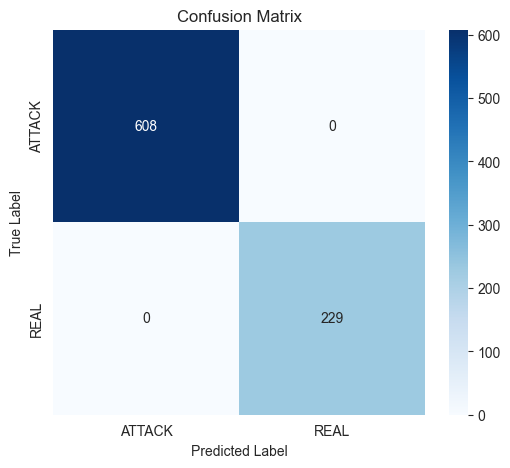

Confusion Matrix:
[[608   0]
 [  0 229]]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_test_predictions(model, loader, device):
    """Collect all predictions and labels from the test loader."""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labs in loader:
            imgs = imgs.to(device)
            labs_np = labs.numpy().ravel()

            probs = model(imgs).cpu().numpy().ravel()
            preds = (probs >= 0.5).astype(int)

            all_probs.append(probs)
            all_labels.append(labs_np)

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    all_preds = (all_probs >= 0.5).astype(int)

    return all_labels, all_preds, all_probs


def plot_confusion_matrix(labels, preds):
    """Plot confusion matrix for binary classification."""
    cm = confusion_matrix(labels, preds, labels=[0, 1])  # enforce ATTACK=0, REAL=1

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["ATTACK", "REAL"],
        yticklabels=["ATTACK", "REAL"],
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    print("Confusion Matrix:")
    print(cm)


# ---- RUN CONFUSION MATRIX ----
labels, preds, probs = get_test_predictions(model, test_loader, device)
plot_confusion_matrix(labels, preds)
